In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)


In [2]:
class LinearTaskSampler:
    def __init__(self, d, n, batch_tasks, out_dim=1, x_range=1.0, device="cpu"):
        self.d, self.n, self.B = d, n, batch_tasks
        self.out_dim = out_dim
        self.x_range = x_range
        self.device = device

    def sample_batch(self, noise_std=0.0):
        B, d, n = self.B, self.d, self.n
        W = torch.randn(B, self.out_dim, d, device=self.device)
        X = (2*self.x_range)*torch.rand(B, n, d, device=self.device) - self.x_range
        Y_clean = torch.einsum("bnd, bod->bno", X, W)
        x_q = (2*self.x_range)*torch.rand(B, d, device=self.device) - self.x_range
        y_q = torch.einsum("bd, bod->bo", x_q, W)

        if noise_std > 0.0:
            noise = noise_std * torch.randn_like(Y_clean)
            Y_noisy = Y_clean + noise
        else:
            Y_noisy = Y_clean

        return X, Y_clean, Y_noisy, x_q, y_q, W


In [3]:
class LinearSelfAttention1L(nn.Module):
    def __init__(self, token_dim):
        super().__init__()
        D = token_dim
        self.W_Q = nn.Linear(D, D, bias=False)
        self.W_K = nn.Linear(D, D, bias=False)
        self.W_V = nn.Linear(D, D, bias=False)
        self.P   = nn.Linear(D, D, bias=False)

    def forward(self, tokens):
        Q = self.W_Q(tokens)
        K = self.W_K(tokens)
        V = self.W_V(tokens)
        att = torch.einsum("bid,bjd->bij", K, Q)
        val = torch.einsum("bij,bjd->bid", att, V)
        return tokens + self.P(val)


In [4]:
def build_tokens(X, Y, x_q, out_dim=1):
    B, n, d = X.shape
    y_q_init = torch.zeros(B, out_dim, device=X.device)
    ctx = torch.cat([X, Y], dim=-1)
    q = torch.cat([x_q, y_q_init], dim=-1).unsqueeze(1)
    return torch.cat([ctx, q], dim=1)

def readout(updated, out_dim=1):
    return updated[:, -1, -out_dim:]


In [5]:
def gd_one_step(X, Y, x_q, lr):
    B, n, d = X.shape
    delta = (lr/n) * (X * Y).sum(dim=1)
    return (delta * x_q).sum(dim=-1, keepdim=True)


In [6]:
d, n = 10, 21
batch_tasks = 256
num_steps = 2000
gd_lr = 0.5

noise_levels = [0.0, 0.1, 0.2, 0.3]
results = {}


In [7]:
def run_noise_experiment(noise_std):
    sampler = LinearTaskSampler(d=d, n=n, batch_tasks=batch_tasks, device=device)
    model = LinearSelfAttention1L(token_dim=d+1).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    for step in range(1, num_steps+1):
        X, Y_clean, Y_noisy, x_q, y_q, _ = sampler.sample_batch(noise_std=noise_std)
        X, Y_clean, Y_noisy = X.to(device), Y_clean.to(device), Y_noisy.to(device)
        x_q, y_q = x_q.to(device), y_q.to(device)

        tokens = build_tokens(X, Y_noisy, x_q)
        out = model(tokens)
        y_lsa = readout(out)

        with torch.no_grad():
            y_gd = gd_one_step(X, Y_noisy, x_q, lr=gd_lr)

        loss = F.mse_loss(y_lsa, y_q)
        opt.zero_grad()
        loss.backward()
        opt.step()

    X, Y_clean, Y_noisy, x_q, y_q, _ = sampler.sample_batch(noise_std=noise_std)
    X, Y_clean, Y_noisy = X.to(device), Y_clean.to(device), Y_noisy.to(device)
    x_q, y_q = x_q.to(device), y_q.to(device)

    y_lsa = readout(model(build_tokens(X, Y_noisy, x_q)))
    y_gd = gd_one_step(X, Y_noisy, x_q, gd_lr)

    mse_lsa = F.mse_loss(y_lsa, y_q).item()
    mse_gd  = F.mse_loss(y_gd,  y_q).item()
    cos_sim = F.cosine_similarity(y_lsa, y_gd).mean().item()

    return mse_lsa, mse_gd, cos_sim


In [8]:
for noise in noise_levels:
    mse_lsa, mse_gd, cos_sim = run_noise_experiment(noise)
    results[noise] = {
        "mse_lsa": mse_lsa,
        "mse_gd": mse_gd,
        "cos": cos_sim,
    }
    print(noise, results[noise])


0.0 {'mse_lsa': 1.0082767009735107, 'mse_gd': 2.3593640327453613, 'cos': 0.953125}
0.1 {'mse_lsa': 1.125199794769287, 'mse_gd': 2.367410182952881, 'cos': 0.953125}
0.2 {'mse_lsa': 1.0393708944320679, 'mse_gd': 2.3257360458374023, 'cos': 0.9453125}
0.3 {'mse_lsa': 1.1451717615127563, 'mse_gd': 2.6642117500305176, 'cos': 0.9453125}


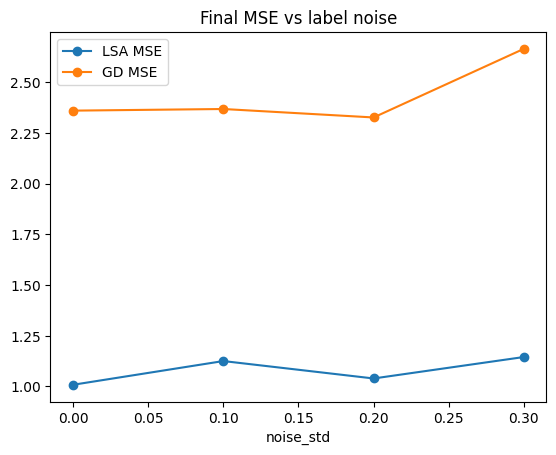

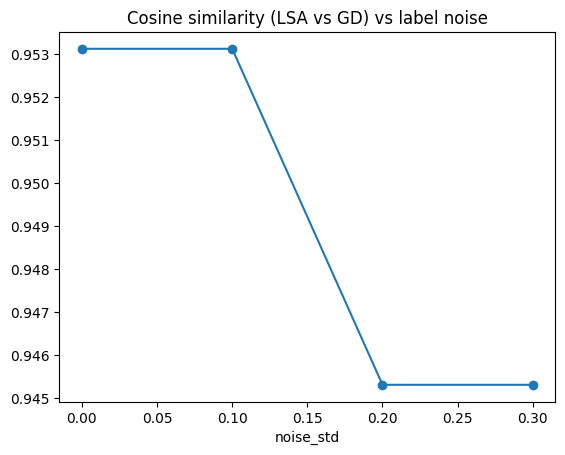

In [9]:
xs = noise_levels
mse_lsa = [results[n]["mse_lsa"] for n in xs]
mse_gd  = [results[n]["mse_gd"] for n in xs]
cos_vals = [results[n]["cos"] for n in xs]

plt.figure()
plt.plot(xs, mse_lsa, marker="o", label="LSA MSE")
plt.plot(xs, mse_gd, marker="o", label="GD MSE")
plt.xlabel("noise_std")
plt.title("Final MSE vs label noise")
plt.legend()
plt.show()

plt.figure()
plt.plot(xs, cos_vals, marker="o")
plt.xlabel("noise_std")
plt.title("Cosine similarity (LSA vs GD) vs label noise")
plt.show()
